# Reproducing the phase mask optimization figures

This notebook reproduces the figures used in the paper. For an explanation of the simulation, CNN, and training workflow, see the [phase mask optimization tutorial](DTEx252_phase_mask_optimization.ipynb).

In [1]:
import deeptrack as dt

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from lightning.pytorch import seed_everything
seed_everything(100, workers=True);

Seed set to 100


In [2]:
from deeptrack.backend import config

config.set_backend("torch")

if torch.cuda.is_available():
    config.set_device("cuda")
else:
    config.set_device("cpu")

device = config.get_device()
print(config.get_backend(), config.get_device())

torch cuda


Define the trainable phase mask

In [3]:
class LearnablePhaseMask(nn.Module, dt.Aberration):
    """Applies a learnable phase mask to the pupil function."""

    def __init__(self, shape=(144, 144), **kwargs):
        dt.Aberration.__init__(self, **kwargs)
        super().__init__(**kwargs)

        # Trainable phase mask parameter
        self.phase = nn.Parameter(torch.zeros(shape, dtype=torch.float32))

    def forward(self, pupil: torch.Tensor, **kwargs) -> torch.Tensor:
        """PyTorch forward pass for use in training"""
        return self.apply_phase(pupil)

    def get(self, pupil: torch.Tensor, **kwargs) -> torch.Tensor:
        """DeepTrack Feature graph call"""
        return self.apply_phase(pupil)

    def apply_phase(self, pupil: torch.Tensor) -> torch.Tensor:
        """Shared implementation of phase modulation"""
        phase = self.phase.to(device)
        phase_mask = torch.cos(phase) + 1j * torch.sin(phase)
        return pupil * phase_mask

Define the optical setup

In [4]:
image_size = 121
depth = 51  # Number of axial slices (z-planes)
margin = 20  # pixel margin kept clear near the xy image border

axial_range = 5e-6
z_spacing = axial_range / depth

magnification = 100

Define the optics, both for the case with and without the phase mask.

In [5]:
phase_mask = LearnablePhaseMask()

optics = dt.Fluorescence(
    NA=1.45,
    refractive_index_medium=1.33,
    output_region=(0, 0, image_size, image_size),
    pupil=phase_mask,
    wavelength=0.58e-6,
    resolution=(11e-6, 11e-6, z_spacing * magnification),
    magnification=magnification,
)

# optics for the case with no phase mask
optics_npm = dt.Fluorescence(
    NA=1.45,
    refractive_index_medium=1.33,
    output_region=(0, 0, image_size, image_size),
    wavelength=0.58e-6,
    resolution=(11e-6, 11e-6, z_spacing * magnification),
    magnification=magnification,
)

Create 100 samples of positions

In [6]:
num_samples = 100

volume_shape = torch.tensor([image_size, image_size, depth])
margin_shape = torch.tensor([2 * margin, 2 * margin, 0])
margin_offset = torch.tensor([margin, margin, 0])

all_points = []
for _ in range(num_samples):
    n = int(torch.randint(low=1, high=35, size=(1,)))
    all_points.append(torch.rand(n, 3) * (volume_shape - margin_shape) + margin_offset)

Create the particle simulations. Here we create paired simulations, so that the case with and without the phase mask have the same number of particles in the same positions, and the same noise.

In [7]:
class FixedPositions(dt.Feature):
    """Place particles at given positions instead of random ones."""

    def get(self, image, points, **kwargs):
        mask = torch.zeros(image.shape[:3], dtype=float)

        for p in points:
            mask[
                torch.round(p[0]).long().clamp(0, image.shape[0] - 1),
                torch.round(p[1]).long().clamp(0, image.shape[1] - 1),
                torch.round(p[2]).long().clamp(0, image.shape[2] - 1),
            ] = 1

        self.points = points

        return mask + image

In [8]:
class PoissonApprox(dt.Noise):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def get(self, image, noise_scale, **kwargs):
        image = torch.clamp(image, min=0.0)
        noise = torch.sqrt(image) * torch.randn_like(image, device=self.device)
        noisy_image = image + noise * noise_scale
        return noisy_image

In [9]:
class NonUniformBackground(dt.Noise):
    def get(self, image, center, width, angle, valley, peak, **kwargs):
        # Image shape: (H, W, 1)
        H, W = image.shape[:2]
        y = torch.arange(H, device=image.device, dtype=image.dtype)
        x = torch.arange(W, device=image.device, dtype=image.dtype)
        yy, xx = torch.meshgrid(y, x, indexing="ij")

        # Shift the origin to the center of the spot
        xx = xx - (W - 1) / 2 - center[0]
        yy = yy - (H - 1) / 2 - center[1]

        # Rotate the coordinates by `angle`
        c, s = np.cos(angle), np.sin(angle)
        xr = c * xx + s * yy
        yr = -s * xx + c * yy

        # Smooth elliptical profile, brightest at the spot center
        r = (xr / (width[0] * W)) ** 2 / 2
        r = r + (yr / (width[1] * H)) ** 2 / 2
        profile = torch.exp(-(r**2))

        # Rescale the profile to [0, 1], then to [valley, peak]
        profile = (profile - profile.min()) / (
            profile.max() - profile.min()
        ).clamp_min(1e-8)

        background = valley + (peak - valley) * profile
        return image + background[..., None]

In [10]:
class NormalizePhotons(dt.Feature):
    def get(self, image, photons, **kwargs):
        return image * photons / image.sum().clamp_min(1e-12)

In [11]:
class RenderParticles(dt.StructuralFeature):
    def __init__(self, single_particle_image, **kwargs):
        super().__init__(**kwargs)
        self.single_particle_image = self.add_feature(single_particle_image)

    def get(self, inputs, **kwargs):
        global i

        # Resolve the scene once and start at its first particle.
        gt_pip.resolve()
        i = -1

        images = []
        for _ in range(len(xyz.points)):
            # Refresh cached particle properties and render the next particle.
            image = self.single_particle_image.update().resolve()
            images.append(image)

        return torch.stack(images, dim=0).sum(dim=0)

In [12]:
current_points = all_points[4]
sample_idx = -1

xyz = FixedPositions(points=lambda: current_points)

i = -1

def next_position():
    global i
    gt_pip.resolve()
    i = (i + 1) % len(xyz.points)
    # return xyz.points[i]
    x, y, z_bin = xyz.points[i]
    z_physical = z_bin - depth / 2  # center on focus for rendering only
    return torch.stack([x, y, z_physical])

particle = dt.PointParticle(position=next_position, intensity=1)

gt_pip = (
    dt.Value(torch.zeros((image_size, image_size, depth), dtype=float)) >> xyz
)

noise_poisson = PoissonApprox(noise_scale=1.0)

noise_bg = NonUniformBackground(
    center=lambda: np.random.uniform(-10, 10, size=2),
    width=lambda: np.random.uniform(0.2, 0.4, size=2),
    angle=lambda: np.random.uniform(-np.pi / 4, np.pi / 4),
    valley=lambda: np.random.uniform(20, 30),
    peak=lambda: np.random.uniform(100, 150),
    signal_per_photon=1.0,
)

per_emitter_blur = dt.GaussianBlur(
    sigma=lambda: np.random.uniform(0.75, 1.25)
)

single_particle_image = (
    optics(particle)                                                            
    >> NormalizePhotons(photons=lambda: np.random.uniform(10_000, 60_000))
    >> per_emitter_blur
)

particles_image = RenderParticles(single_particle_image)

im_pip = particles_image >> noise_bg >> noise_poisson >> dt.NormalizeMinMax()

pip = (im_pip & gt_pip) >> dt.MoveAxis(2, 0)


single_particle_image_npm = (
    optics_npm(particle)
    >> NormalizePhotons(photons=lambda: np.random.uniform(10_000, 60_000))
    >> per_emitter_blur
)

particles_image_npm = RenderParticles(single_particle_image_npm)

im_pip_npm = (
    particles_image_npm >> noise_bg >> noise_poisson >> dt.NormalizeMinMax()
)

pip_npm = (im_pip_npm & gt_pip) >> dt.MoveAxis(2, 0)


def resolve_paired_sample():
    """Resolve pip and pip_npm for the next sample in `all_points`, forcing
    both to draw the same random background/photon-count/blur/noise values
    so the comparison isolates the effect of the phase mask alone."""
    global sample_idx, current_points

    sample_idx = (sample_idx + 1) % len(all_points)
    current_points = all_points[sample_idx]

    rng_state = torch.get_rng_state()
    np_state = np.random.get_state()
    cuda_state = torch.cuda.get_rng_state(device)

    pip.update()
    img, gt = pip.resolve()

    torch.set_rng_state(rng_state)
    np.random.set_state(np_state)
    torch.cuda.set_rng_state(cuda_state, device)

    pip_npm.update()
    img_npm, _ = pip_npm.resolve()

    return img, img_npm, gt

tensor(0., device='cuda:0', grad_fn=<MaxBackward1>) tensor(1., device='cuda:0', grad_fn=<MaxBackward1>)


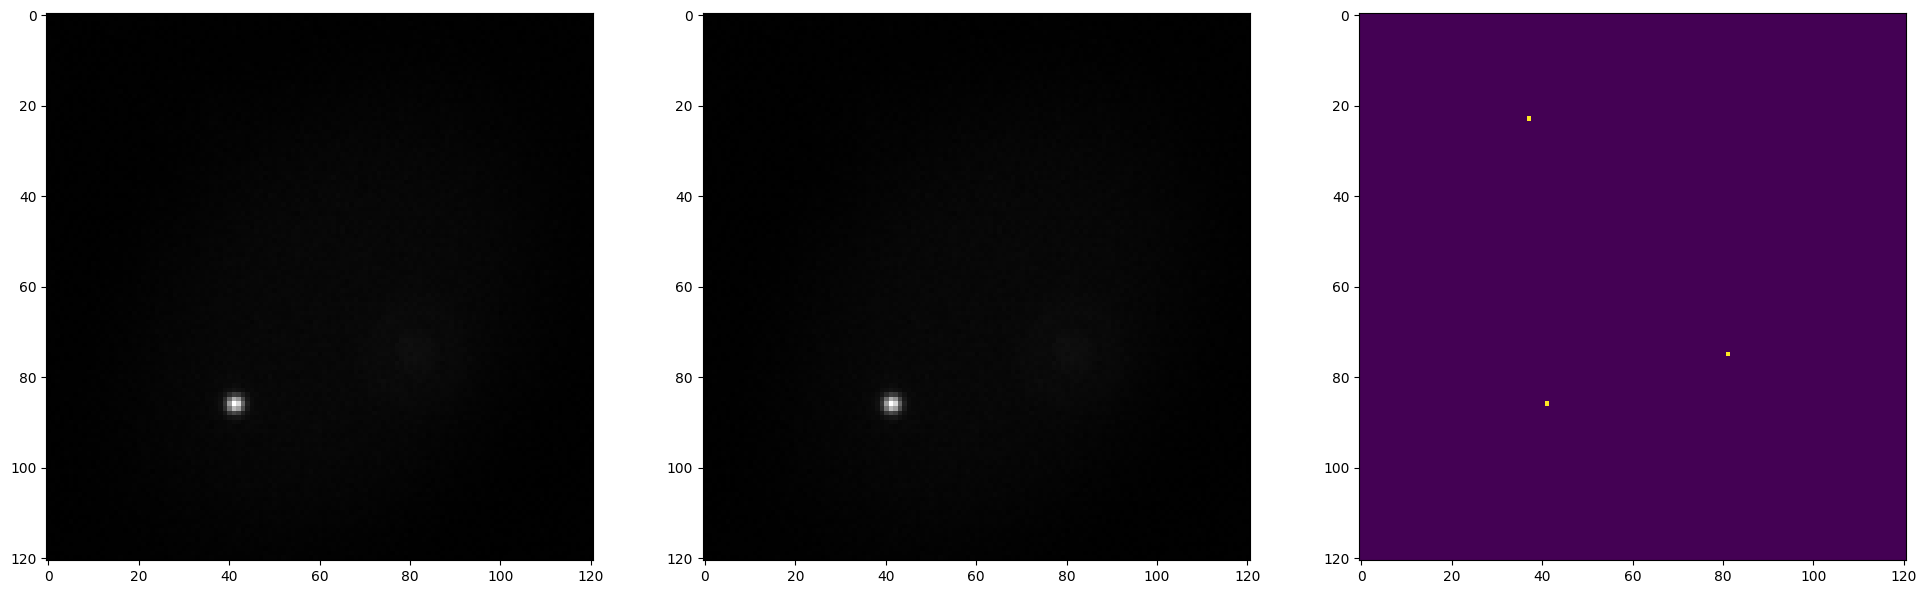

In [13]:
img, img_no, g = resolve_paired_sample()


fig, axs = plt.subplots(1, 3, figsize=(24, 8))

axs[0].imshow(img[0].cpu().detach().numpy(), cmap="gray")
axs[1].imshow(img_no[0].cpu().detach().numpy(), cmap="gray")
axs[2].imshow(g.max(dim=0)[0]);

print((img - img_no).abs().max(), img.abs().max())

Load the CNN

In [14]:
import deeplay as dl


class CNNConcat(dl.ConvolutionalNeuralNetwork):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.input_norm = dl.Layer(torch.nn.BatchNorm2d, num_features=1)

    def forward(self, input):
        normed_input = self.input_norm(input)

        out = None

        for idx, block in enumerate(self.blocks):

            if idx == 0:
                out = block(normed_input)

            elif idx < len(self.blocks) - 1:
                features = torch.cat((out, normed_input), dim=1)
                new_out = block(features)
                out = new_out + out

            else:
                out = block(out)

        return out

In [15]:
hidden_dim = 64

# shared scale: used both for clamping the output of the CNN and as a
# scaling factor in the loss function `loss_fn`
factor = 100.0


CNN = CNNConcat(
    in_channels=1,
    hidden_channels=[hidden_dim + 1] * 8 + [hidden_dim],
    out_channels=depth,
)

CNN[..., "activation"].all.configure(
    nn.LeakyReLU, negative_slope=0.2, inplace=True
)
CNN[...].isinstance(dl.Conv2dBlock).all.normalized(torch.nn.BatchNorm2d)
CNN[..., "normalization"].all.configure(num_features=hidden_dim)

CNN[..., "layer#:-1"].configure(out_channels=hidden_dim)

CNN["blocks", "9", "layer"].configure(kernel_size=1, padding=0)
CNN["blocks", "9"].remove("normalization", allow_missing=True)
CNN[..., "activation#-1"].configure(nn.Hardtanh, min_val=0.0, max_val=factor);

Load the weights from the trained cnns and the phase mask:

In [16]:
from pathlib import Path

checkpoint_path = (Path("assets") / "phase_mask_optimization" / "best_weights.pt")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

cnn = CNN.create().to(device)

cnn.load_state_dict(checkpoint["cnn"])
cnn.eval()
phase_mask.load_state_dict(checkpoint["phase_mask"])
phase_mask.eval()

checkpoint_path_npm = (Path("assets") / "phase_mask_optimization" / "best_weights_npm.pt")
checkpoint_npm = torch.load(checkpoint_path_npm, map_location=device, weights_only=True)

cnn_npm = CNN.create().to(device)
cnn_npm.load_state_dict(checkpoint_npm["cnn"])
cnn_npm.eval()

CNNConcat(
  (blocks): LayerList(
    (0): Conv2dBlock(
      (layer): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.2, inplace=True)
      (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1-8): 8 x Conv2dBlock(
      (layer): Conv2d(65, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.2, inplace=True)
      (normalization): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (9): Conv2dBlock(
      (layer): Conv2d(64, 51, kernel_size=(1, 1), stride=(1, 1))
      (activation): Hardtanh(min_val=0.0, max_val=100.0, inplace=True)
    )
  )
  (input_norm): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

Create an image pair with the same positions and noises for both the case with and without the phase mask.

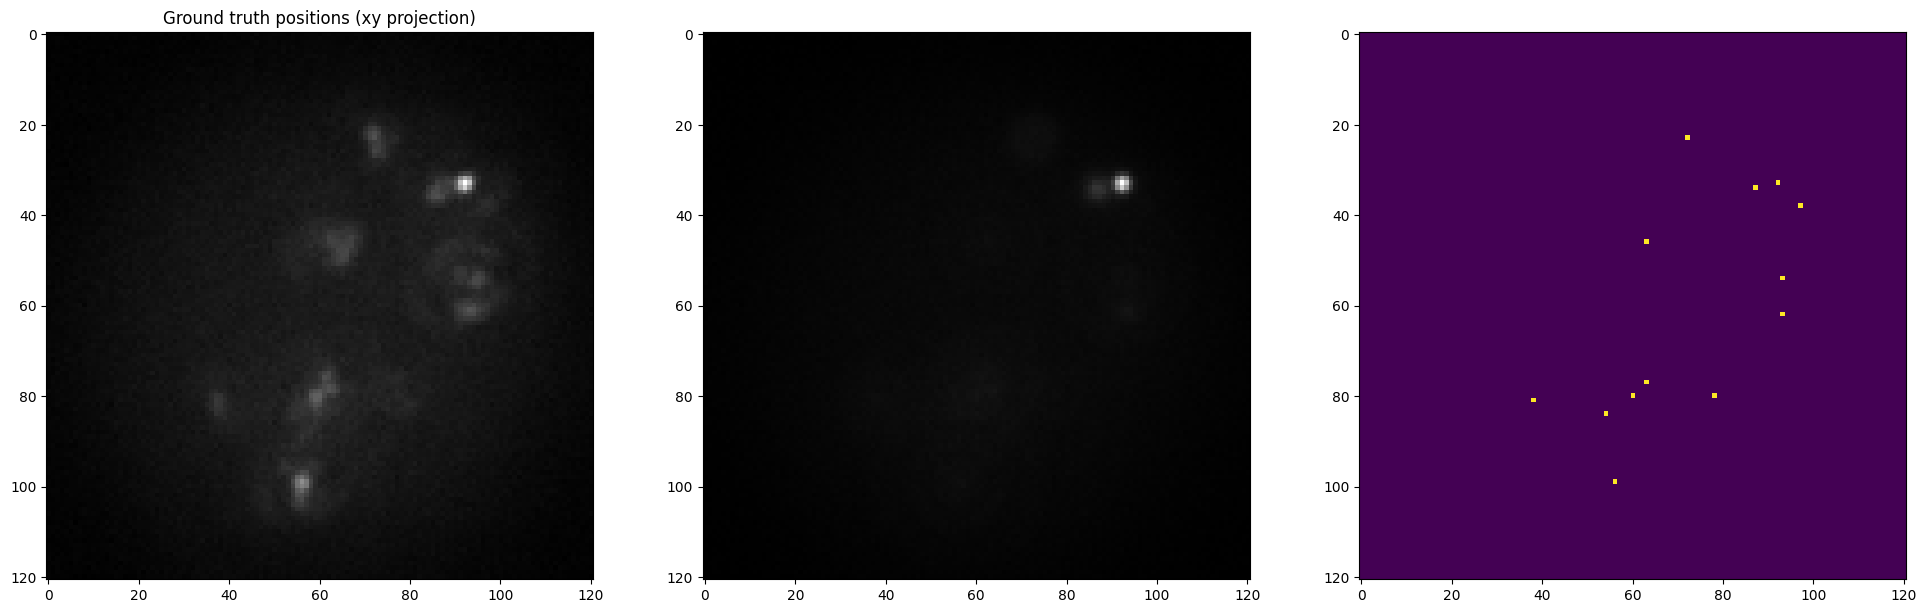

In [17]:
img, img_npm, gt = resolve_paired_sample()

fig, axs = plt.subplots(1, 3, figsize=(24, 8))

axs[0].imshow(img[0].cpu().detach().numpy(), cmap="gray")
axs[0].set_title('With phase mask')
axs[1].imshow(img_npm[0].cpu().detach().numpy(), cmap="gray")
axs[0].set_title('Without phase mask')
axs[2].imshow(gt.max(dim=0)[0])
axs[0].set_title('Ground truth positions (xy projection)');

with torch.inference_mode():
    pred = cnn(
        img.unsqueeze(0).to(device=device, dtype=torch.float32)
    )
    pred_npm = cnn_npm(
        img_npm.unsqueeze(0).to(device=device, dtype=torch.float32)
    )

Phase mask statistics, min: -3.247, max: 3.874, mean: -0.001


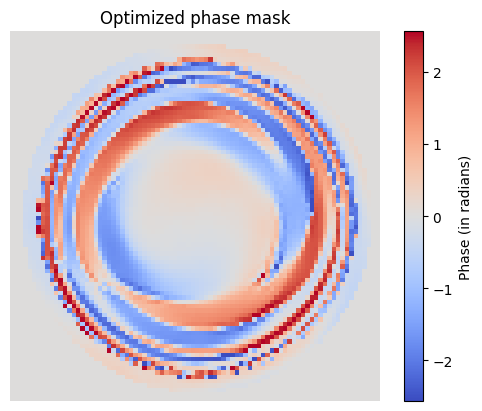

In [18]:
from matplotlib.colors import CenteredNorm

phase_mask_after = phase_mask.phase.detach().cpu().numpy()
print(
    f"Phase mask statistics, min: {phase_mask_after.min():.3f}, "
    f"max: {phase_mask_after.max():.3f}, "
    f"mean: {phase_mask_after.mean():.3f}"
)

crop = phase_mask_after[30:-30, 30:-30]
plt.imshow(
    crop,
    cmap="coolwarm",
    norm=CenteredNorm(halfrange=np.percentile(np.abs(crop), 99)),
    interpolation="nearest",
)
plt.colorbar(label="Phase (in radians)")
plt.title("Optimized phase mask")
plt.axis("off")
plt.show()

Extract particle positions

In [19]:
from torch.nn.functional import conv3d


# convert gpu tensors to numpy
def tensor_to_np(x):
    return np.atleast_1d(np.squeeze(x.detach().cpu().numpy()))


# post-processing module: thresholding and local maxima finding
class Postprocess(nn.Module):
    def __init__(self, device, thresh, radius, keep_singlez=False):
        """
        Parameters:
        -----------
        device : torch device
            GPU/CPU device to run on
        thresh : float
            Minimum confidence threshold for candidate detections
        radius : int
            Neighborhood radius (defines local region size = 2r+1)
        keep_singlez : bool
            If True, keep only one z-maximum per (x, y) location
        """
        super().__init__()
        self.device = device
        self.thresh = thresh
        self.r = radius
        self.keep_singlez = keep_singlez

        # Max pooling layers for local maxima detection
        self.maxpool = nn.MaxPool3d(
            kernel_size=2 * self.r + 1, stride=1, padding=self.r
        )
        self.maxpool2 = nn.MaxPool2d(
            kernel_size=2 * self.r + 1, stride=1, padding=self.r
        )

        self.pad = nn.ConstantPad3d(self.r, 0.0)
        self.zero = torch.FloatTensor([0.0]).to(self.device)

        # Construct local filters for sub-voxel refinement
        filt_vec = np.arange(-self.r, self.r + 1)
        yfilter, zfilter, xfilter = np.meshgrid(filt_vec, filt_vec, filt_vec)
        xfilter = torch.FloatTensor(xfilter).unsqueeze(0).unsqueeze(0)
        yfilter = torch.FloatTensor(yfilter).unsqueeze(0).unsqueeze(0)
        zfilter = torch.FloatTensor(zfilter).unsqueeze(0).unsqueeze(0)
        sfilter = torch.ones_like(xfilter)
        self.local_filter = torch.cat(
            (sfilter, xfilter, yfilter, zfilter), 0
        ).to(self.device)

    def keep_maxz(self, conf_vol):
        """Keep only the strongest maximum along z for each (x, y)."""

        D, H, W = conf_vol.shape

        max_proj, _ = torch.max(conf_vol, dim=0, keepdim=True)

        # keep only local maxima in 2d
        max_proj = self.maxpool2(max_proj.unsqueeze(0))
        max_proj = max_proj.squeeze(0)

        # keep only maximum
        conf_vol_out = torch.where(
            conf_vol == max_proj.expand(D, H, W), conf_vol, self.zero
        )

        return conf_vol_out

    def local_avg(self, xbool, ybool, zbool, pred_vol_pad, num_pts, device):
        """Compute sub-voxel position refinement using local weighted averages."""

        # Collect local (2r+1)^3 cubes around each candidate
        pred_vol_all = torch.zeros(
            num_pts, 1, self.r * 2 + 1, self.r * 2 + 1, self.r * 2 + 1
        ).to(device)
        for pt in range(num_pts):

            # local 3D volume
            xpt = [xbool[pt], xbool[pt] + 2 * self.r + 1]
            ypt = [ybool[pt], ybool[pt] + 2 * self.r + 1]
            zpt = [zbool[pt], zbool[pt] + 2 * self.r + 1]
            pred_vol_all[pt, :] = pred_vol_pad[
                :, :, zpt[0] : zpt[1], ypt[0] : ypt[1], xpt[0] : xpt[1]
            ]

        # convolve it using conv3d
        sums = conv3d(pred_vol_all, self.local_filter)

        # squeeze the sums and convert them to local perturbations
        xloc = sums[:, 1] / sums[:, 0]
        yloc = sums[:, 2] / sums[:, 0]
        zloc = sums[:, 3] / sums[:, 0]

        return xloc, yloc, zloc

    def forward(self, pred_vol):
        """Main postprocessing pipeline:
        Input:  3D confidence volume (output of network)
        Output: xyz_rec (N×3 array of particle coordinates),
                conf_rec (N array of confidences)
        """

        # Ensure 5D tensor shape: (B, C, D, H, W)
        num_dims = len(pred_vol.size())
        if np.not_equal(num_dims, 5):
            if num_dims == 4:
                pred_vol = pred_vol.unsqueeze(0)
            else:
                pred_vol = pred_vol.unsqueeze(0)
                pred_vol = pred_vol.unsqueeze(0)

        # Thresholding
        pred_thresh = torch.where(pred_vol > self.thresh, pred_vol, self.zero)

        # 3D local maxima detection
        conf_vol = self.maxpool(pred_thresh)
        conf_vol = torch.where(
            (conf_vol > self.zero) & (conf_vol == pred_thresh),
            conf_vol,
            self.zero,
        )

        # Optionally keep only a single z in each xy sub-pixel
        if self.keep_singlez:
            conf_vol = torch.squeeze(conf_vol)
            conf_vol = self.keep_maxz(conf_vol)

        # Find locations of confs (bigger than 0)
        conf_vol = torch.squeeze(conf_vol)
        batch_indices = torch.nonzero(conf_vol)
        zbool, ybool, xbool = (
            batch_indices[:, 0],
            batch_indices[:, 1],
            batch_indices[:, 2],
        )

        # If no detections, return None
        if len(zbool) == 0:
            xyz_rec = None
            conf_rec = None

        else:
            # Sub-voxel refinement
            # pad the result with radius_px 0's for average calc.
            pred_vol_pad = self.pad(pred_vol)

            # for each point calculate local weighted average
            num_pts = len(zbool)
            xloc, yloc, zloc = self.local_avg(
                xbool, ybool, zbool, pred_vol_pad, num_pts, self.device
            )

            # Convert lists and tensors to NumPy
            xloc, yloc, zloc = (
                tensor_to_np(xloc),
                tensor_to_np(yloc),
                tensor_to_np(zloc),
            )
            xbool, ybool, zbool = (
                tensor_to_np(xbool),
                tensor_to_np(ybool),
                tensor_to_np(zbool),
            )

            # Calculate the recovered positions assuming mid-voxel
            xrec = xbool + xloc
            yrec = ybool + yloc
            zrec = zbool + zloc

            # rearrange the result into a Nx3 array
            xyz_rec = np.column_stack((xrec, yrec, zrec))

            # Extract confidence values
            conf_rec = conf_vol[zbool, ybool, xbool]
            conf_rec = tensor_to_np(conf_rec)

            xyz_rec, conf_rec = self.remove_duplicates(xyz_rec, conf_rec)

        return xyz_rec, conf_rec

    def remove_duplicates(self, xyz_rec, conf_rec, tol=1e-4):
        """Keep the first position in each rounded coordinate bin, with its
        confidence."""
        if xyz_rec is None or len(xyz_rec) == 0:
            return xyz_rec, conf_rec

        rounded = np.round(xyz_rec / tol).astype(np.int64)
        _, unique_idx = np.unique(rounded, axis=0, return_index=True)
        unique_idx = np.sort(unique_idx)

        xyz_rec = xyz_rec[unique_idx]
        if conf_rec is not None:
            conf_rec = conf_rec[unique_idx]

        return xyz_rec, conf_rec

Performance evaluation

In [20]:
def count_matches(pred, target, postprocessing, max_dist=2):
    """
    Match predictions to ground truth and count TP, FP and FN.

    pred: tensor with first dimension as batch
    target: tensor with first dimension as batch
    """
    xyz_rec, conf_rec = postprocessing(pred)
    xyz_target = torch.nonzero(target)[:, [2, 1, 0]]

    if xyz_rec is None or len(xyz_rec) == 0:
        # return torch.tensor(0.0)
        return 0, 0, len(xyz_target)  # TP, FP, FN

    D = torch.cdist(torch.tensor(xyz_rec), xyz_target.cpu().to(torch.float64))

    # Each prediction and ground truth can only be part of one TP
    matched_pred = set()
    matched_gt = set()
    TP = 0
    while True:
        min_val, idx = torch.min(D.view(-1), dim=0)
        if min_val > max_dist or not torch.isfinite(min_val):
            break
        i = idx // D.size(1)
        j = idx % D.size(1)
        TP += 1
        matched_pred.add(i.item())
        matched_gt.add(j.item())
        D[i, :] = float("inf")
        D[:, j] = float("inf")

    FP = len(xyz_rec) - TP
    FN = len(xyz_target) - TP

    return TP, FP, FN

In [21]:
def detection_metrics(TP, FP, FN, eps=1e-6):
    """Compute Jaccard index, Precision, Recall and F1 score"""

    JI = TP / (TP + FP + FN + eps)
    Precision = TP / (TP + FP + eps)
    Recall = TP / (TP + FN + eps)
    F1 = 2 * TP / (2 * TP + FP + FN + eps)

    return JI, Precision, Recall, F1

In [22]:
postprocessing_module = Postprocess(
    device, thresh=20, radius=2, keep_singlez=False
)

In [23]:
num_tests = 100
ji = []
precision = []
recall = []
f1 = []

cnn.eval()

ji_npm = []
precision_npm = []
recall_npm = []
f1_npm = []

cnn_npm.eval()

for j in range(num_tests):
    img, img_npm, g = resolve_paired_sample()

    g = g.to(device)

    pred = cnn(img.unsqueeze(0))
    pred_npm = cnn_npm(img_npm.unsqueeze(0))

    tp, fp, fn = count_matches(pred, g, postprocessing_module)
    tp_npm, fp_npm, fn_npm = count_matches(pred_npm, g, postprocessing_module)

    jaccard_index, precision_score, recall_score, f1_score = detection_metrics(
        tp, fp, fn
    )
    jaccard_index_npm, precision_score_npm, recall_score_npm, f1_score_npm = detection_metrics(
            tp_npm, fp_npm, fn_npm
        )

    ji.append(jaccard_index)
    precision.append(precision_score)
    recall.append(recall_score)
    f1.append(f1_score)

    ji_npm.append(jaccard_index_npm)
    precision_npm.append(precision_score_npm)
    recall_npm.append(recall_score_npm)
    f1_npm.append(f1_score_npm)

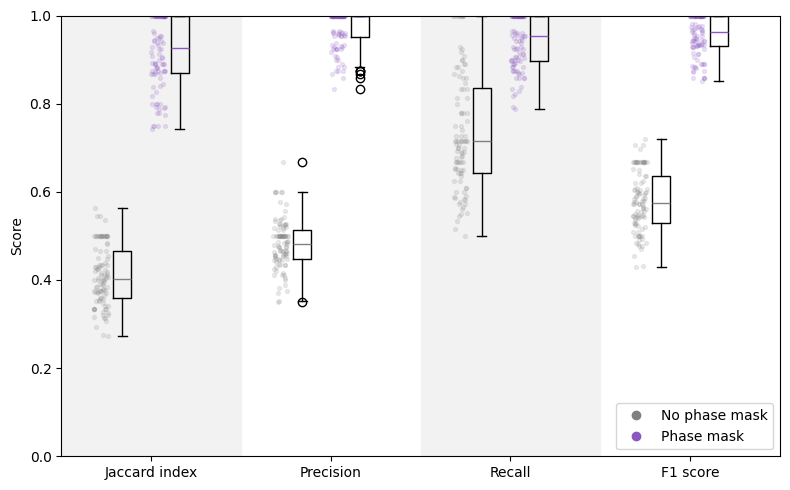

In [24]:
from matplotlib.lines import Line2D

metrics = {
    "Jaccard index": [ji_npm, ji],
    "Precision": [precision_npm, precision],
    "Recall": [recall_npm, recall],
    "F1 score": [f1_npm, f1],
}

labels = ["No phase mask", "Phase mask"]
colors = ["gray", "#8c56c3ff"]
offsets = [-0.16, 0.16]

rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(8, 5))

for m, values in enumerate(metrics.values()):
    for i, v in enumerate(values):
        ax.boxplot(
            v,
            positions=[m + offsets[i]],
            widths=0.1,
            medianprops=dict(color=colors[i]),
        )

        x = m + offsets[i] + rng.uniform(-0.04, 0.04, len(v)) - 0.12
        ax.scatter(x, v, s=8, alpha=0.15, color=colors[i])

for m in range(0, len(metrics), 2):
    ax.axvspan(m - 0.5, m + 0.5, color="0.95", zorder=0)


ax.set_xticks(range(len(metrics)), list(metrics))
ax.set_xlim(-0.5, len(metrics) - 0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.legend(
    handles=[
        Line2D([], [], color=c, marker="o", ls="", ms=6, label=l)
        for c, l in zip(colors, labels)
    ],
    loc="lower right",
)

fig.tight_layout()

In [25]:
print(f"{'':<15}{'No phase mask':>12}{'Phase mask':>15}")
for name, (with_mask, without_mask) in metrics.items():
    print(
        f"{name:<15}"
        f"{np.median(with_mask):>12.3f}"
        f"{np.median(without_mask):>15.3f}"
    )

               No phase mask     Phase mask
Jaccard index         0.402          0.926
Precision             0.482          1.000
Recall                0.714          0.955
F1 score              0.574          0.961


Change the shape of the plot

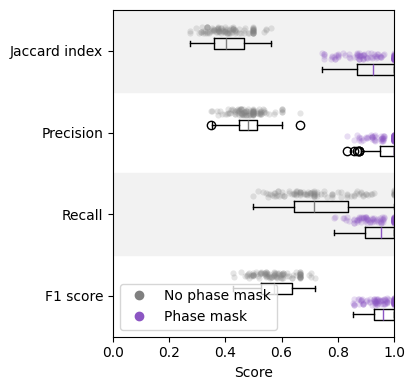

In [26]:
metrics = {
    "Jaccard index": [ji_npm, ji],
    "Precision": [precision_npm, precision],
    "Recall": [recall_npm, recall],
    "F1 score": [f1_npm, f1],
}

labels = ["No phase mask", "Phase mask"]
colors = ["gray", "#8c56c3ff"]
offsets = [-0.16, 0.16]
shift = 0.0675

rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(4.25, 4))

for m, values in enumerate(metrics.values()):
    for i, v in enumerate(values):
        ax.boxplot(
            v,
            positions=[m + offsets[i] + shift],
            widths=0.13,
            vert=False,
            medianprops=dict(color=colors[i]),
        )

        y = m + offsets[i] + rng.uniform(-0.04, 0.04, len(v)) - 0.16 + shift
        ax.scatter(v, y, s=20, alpha=0.2, color=colors[i], linewidths=0)

for m in range(0, len(metrics), 2):
    ax.axhspan(m - 0.5, m + 0.5, color="0.95", zorder=0)

ax.set_yticks(range(len(metrics)), list(metrics))
ax.set_ylim(len(metrics) - 0.5, -0.5)
ax.set_xlim(0, 1.0)
ax.set_xlabel("Score")
ax.legend(
    handles=[
        Line2D([], [], color=c, marker="o", ls="", ms=6, label=l)
        for c, l in zip(colors, labels)
    ],
    loc="lower left",
)

fig.tight_layout()

Show the particle configuration and image for both the baseline and the phase mask with THE SAME PARTICLE POSITIONS

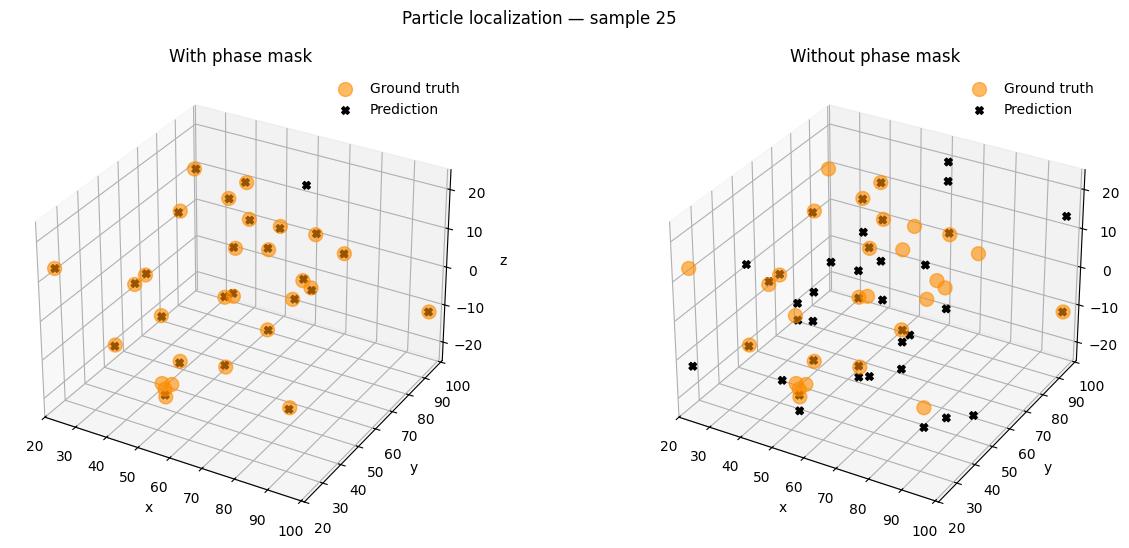

In [27]:
from matplotlib.ticker import MultipleLocator

sample = 25  # zero-based index into all_points      9, 17, 25

if not 0 <= sample < len(all_points):
    raise IndexError(f"sample must be between 0 and {len(all_points) - 1}")

# resolve_paired_sample increments sample_idx before selecting the sample
sample_idx = sample - 1
img, img_npm, gt = resolve_paired_sample()

with torch.inference_mode():
    pred = cnn(
        img.unsqueeze(0).to(device=device, dtype=torch.float32)
    )
    pred_npm = cnn_npm(
        img_npm.unsqueeze(0).to(device=device, dtype=torch.float32)
    )

det, conf = postprocessing_module(pred)
det_npm, conf_npm = postprocessing_module(pred_npm)

# Stored positions use (y, x, z); plotting and detections use (x, y, z).
points = all_points[sample].detach().cpu().numpy()
points_xyz = points[:, [1, 0, 2]]

cases = [
    ("With phase mask", det),
    ("Without phase mask", det_npm),
]

z_center = (depth - 1) / 2  # 25 for depth=51

fig = plt.figure(figsize=(15, 6))

for panel, (title, detections) in enumerate(cases, start=1):
    ax = fig.add_subplot(1, 2, panel, projection="3d")

    # Center ground-truth z coordinates.
    points_plot = points_xyz.copy()
    points_plot[:, 2] -= z_center

    ax.scatter(
        points_plot[:, 0],
        points_plot[:, 1],
        points_plot[:, 2],
        c="darkorange",
        marker="o",
        s=100,
        label="Ground truth",
        alpha=0.6,
        zorder=3,
    )

    if detections is not None and len(detections) > 0:
        detections_plot = np.asarray(detections).copy()
        detections_plot[:, 2] -= z_center

        ax.scatter(
            detections_plot[:, 0],
            detections_plot[:, 1],
            detections_plot[:, 2],
            c="black",
            marker="X",
            s=30,
            label="Prediction",
            alpha=1,
            zorder=4,
        )

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")

    ax.set_xlim(margin, image_size - margin)
    ax.set_ylim(margin, image_size - margin)
    ax.set_zlim(-25, 25)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.zaxis.set_major_locator(MultipleLocator(10))

    ax.legend(frameon=False)

fig.suptitle(f"Particle localization — sample {sample}")

plt.show()

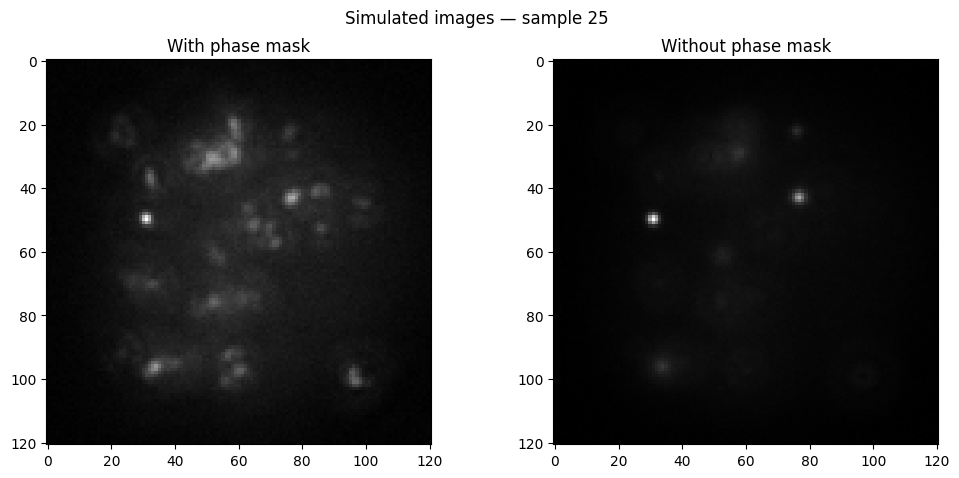

In [28]:
image_with = img.squeeze().detach().cpu().numpy()
image_without = img_npm.squeeze().detach().cpu().numpy()

image_cases = [
    ("With phase mask", image_with, det),
    ("Without phase mask", image_without, det_npm),
]

# Shared display range for a fair visual comparison.
vmin = min(image_with.min(), image_without.min())
vmax = max(image_with.max(), image_without.max())

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for ax, (title, image, detections) in zip(axs, image_cases):
    handle = ax.imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.set_title(title)

fig.suptitle(f"Simulated images — sample {sample}")

plt.show();

Image from a single particle, at varying depth

With and without the phase mask

In [29]:
def im_with_given_z(z):
    centered_particle = dt.PointParticle(
        position=(image_size // 2, image_size // 2),
        intensity=1,
        z=z,
    )

    pip_single = (
        (
            optics(centered_particle)
            >> NormalizePhotons(
                photons=20_000,
            )
        )
        >> dt.NormalizeMinMax()
    ) >> dt.MoveAxis(2, 0)

    pip_npm_single = (
        (
            optics_npm(centered_particle)
            >> NormalizePhotons(
                photons=20_000,
            )
        )
        >> dt.NormalizeMinMax()
    ) >> dt.MoveAxis(2, 0)

    pip_single.update()
    pip_npm_single.update()

    im_with = pip_single.resolve()
    im_without = pip_npm_single.resolve()

    return im_with, im_without

In [30]:
crop_radius = 20
crop_min = image_size // 2 - crop_radius
crop_max = image_size // 2 + crop_radius


def crop(t):
    return t.cpu().detach().numpy()[0][crop_min:crop_max, crop_min:crop_max]


def plot_psf_rows(z_values):
    optimized, baseline = [], []
    for z in z_values:
        im_with, im_without = im_with_given_z(z=z)
        optimized.append(crop(im_with))
        baseline.append(crop(im_without))

    optimized = np.stack(optimized)
    baseline = np.stack(baseline)
    difference = optimized - baseline

    n_cols = len(z_values)
    fig, axs = plt.subplots(
        2, n_cols, figsize=(2.5 * n_cols, 6), layout="constrained"
    )

    rows = [
        ("Standard PSF", baseline, dict(cmap="gray"), False),
        ("Optimized PSF", optimized, dict(cmap="gray"), False),
    ]

    for row_idx, (title, stack, kw, show_cbar) in enumerate(rows):
        for col_idx in range(n_cols):
            ax = axs[row_idx, col_idx]
            handle = ax.imshow(stack[col_idx], **kw)
            ax.set_xticks([])
            ax.set_yticks([])
        axs[row_idx, 0].set_ylabel(title, fontsize=12)


    for col_idx in range(n_cols):
        z_um = z_values[col_idx] * z_spacing * 1e6
        axs[0, col_idx].set_title(
            f"z={z_values[col_idx]:.0f} ({z_um:.2f} µm)", fontsize=12
        )

    plt.show()

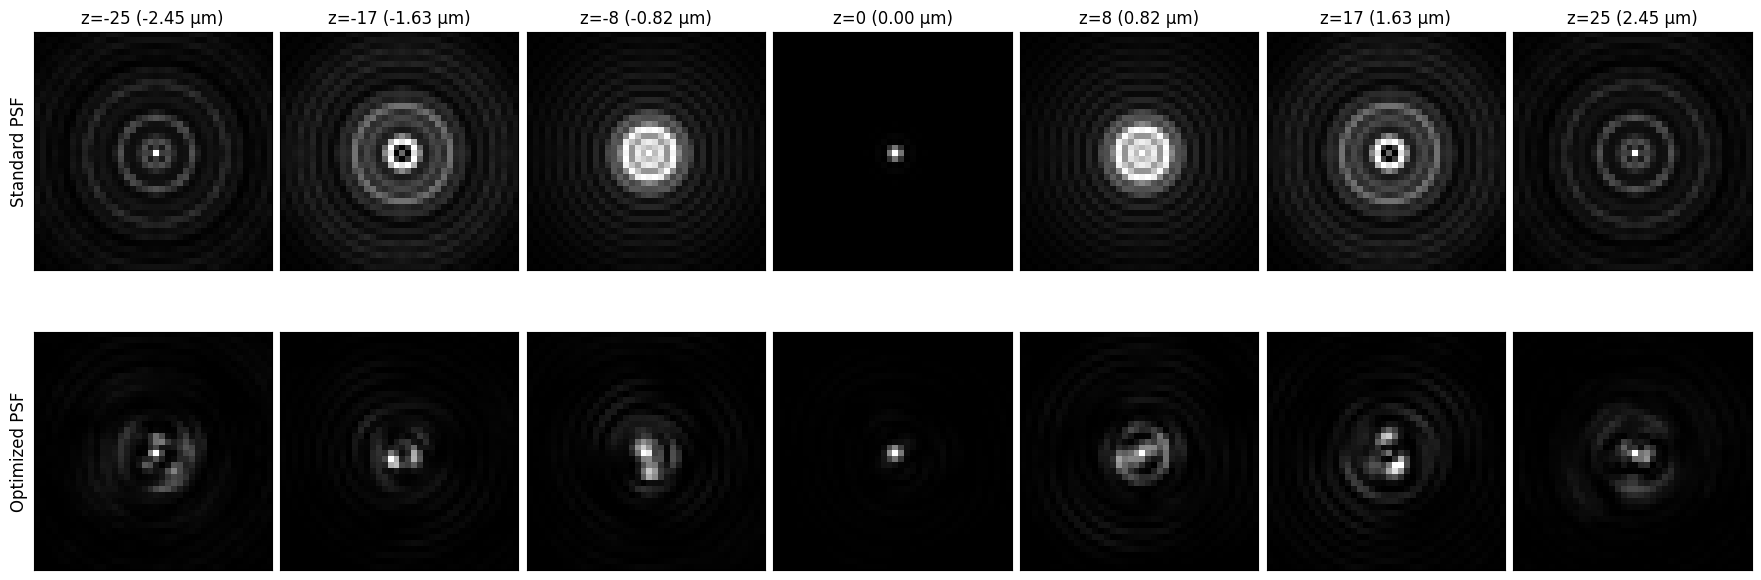

In [31]:
z_values_sparse = np.linspace(-(depth - 1) / 2, (depth - 1) / 2, 7)
plot_psf_rows(z_values_sparse)